# Retail Customer Segmentation (Category-wise KMeans)

## 1)Overview
**Objective:** Build customer segments to support targeted marketing and pricing decisions using transaction data.

**Key Challenges:**
- 95% of customers are one-time buyers, so classic RFM (especially Frequency) is less informative.
- Customers may purchase across multiple product categories, so segmentation is performed **within each category**.

**Method Summary:**
1. Split transactions by `ProductCategory`.
2. Build customer-level features per category (RM-style): `Monetary` (sum spend), `AvgDiscount` (mean/weighted mean).
3. Train **KMeans per category**, select `k` using silhouette + interpretability.
4. Assign business-friendly names to clusters (e.g., VIP / Promo-driven / Full-price).
5. Merge segment labels back to the original dataframe using (`CustomerID`, `ProductCategory`).

**Additional Note (Data Distribution):**
- Some features (e.g., `Recency_days` and sometimes `AvgDiscount`) showed an approximately uniform distribution, meaning they did not strongly separate customer groups on their own.  
- Therefore, feature selection and transformatio(+ robust scaling) were important to produce interpretable clusters.

## 2) Data Loading & Cleaning

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("Retail_Transaction_Dataset.csv")
df.head(10)

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484
5,463050,D,3,54.093152,8/15/2023 4:24,Cash,"8492 Jonathan Drive\nNorth Robertshire, TN 67532",Electronics,10.888768,144.609223
6,888163,D,7,13.121937,12/26/2023 5:32,PayPal,USNV Harrell\nFPO AA 62814,Clothing,16.295127,76.885907
7,843385,A,8,56.025164,10/11/2023 6:48,Debit Card,"489 Juan Loop Apt. 093\nNorth Brettville, WV 7...",Home Decor,6.344306,419.766052
8,839609,B,5,23.857981,2/27/2024 11:13,Credit Card,528 Justin Expressway Apt. 336\nCabreraborough...,Electronics,18.703997,96.977925
9,184135,D,4,63.342777,11/5/2023 1:46,Debit Card,"189 Wright Mews\nMartinfurt, MO 75932",Books,7.640607,234.012018


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB


In [7]:
df.describe()

,CustomerID,Quantity,Price,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,10.020155,248.334955
std,288460.917524,2.579808,25.971567,5.779534,184.554792
min,14.000000,1.000000,10.000430,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,15.018367,362.009980
max,999997.000000,9.000000,99.999284,19.999585,896.141242


In [8]:
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df[df["CustomerID"]==" "]

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount


In [11]:
df[df["Price"]<=0]

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount


In [12]:
df[df["Quantity"]<=0]

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount


In [13]:
df[df["DiscountApplied(%)"]<0]

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount


In [14]:
df["PaymentMethod"].unique()

array(['Cash', 'PayPal', 'Debit Card', 'Credit Card'], dtype=object)

In [15]:
df["ProductCategory"].unique()

array(['Books', 'Home Decor', 'Electronics', 'Clothing'], dtype=object)

In [16]:
df["DiscountApplied(%)"].argmin(),df["DiscountApplied(%)"].max()

(44751, 19.99958523)

In [17]:
df["DiscountApplied(%)"].argmin(),df["DiscountApplied(%)"].min()

(44751, 4.6e-05)

In [18]:
df.iloc[44751]

CustomerID                              198115
ProductID                                    D
Quantity                                     6
Price                                92.069617
TransactionDate                6/18/2023 14:17
PaymentMethod                             Cash
StoreLocation         USNV Welch\nFPO AP 56908
ProductCategory                       Clothing
DiscountApplied(%)                    0.000046
TotalAmount                         552.417449
Name: 44751, dtype: object

In [19]:
df["DATE"]=pd.to_datetime(df["TransactionDate"])
df=df.drop("TransactionDate",axis=1)

## Feature Engineering (RM per Category)

In this step, I transform the dataset from **transaction-level** records to **customer-level** features **within each product category**.  
This is necessary because the segmentation model (KMeans) should cluster **customers** based on their behavior, not individual transactions.

For each `ProductCategory`, I aggregate transactions by `CustomerID` and compute:

- **Monetary**: total spending per customer within the category.
- **Recency_days**: number of days since the customer’s last purchase within the category, computed relative to a global reference date.
- **AvgDiscount**: average discount received by the customer within the category.

These features form the RM table used as input to the clustering stage and robust scaling when needed.

In [21]:
for cat, g in df.groupby("ProductCategory"):
    print(cat, len(g))

Books 25031
Clothing 25056
Electronics 24990
Home Decor 24923


In [22]:
categories={}
for cat,d in df.groupby("ProductCategory"):
    categories[cat]=d.copy()
df_E=categories["Electronics"]
df_B=categories["Books"]
df_C=categories["Clothing"]
df_H=categories["Home Decor"]

In [23]:
df["DATE"].min(),df["DATE"].max()

(Timestamp('2023-04-29 22:27:00'), Timestamp('2024-04-28 22:22:00'))

In [24]:
ref_date=df["DATE"].max().normalize() + pd.Timedelta(days=1)

In [25]:
RM={}
for k,v in categories.items():
    Monetary=v.groupby("CustomerID")["TotalAmount"].sum()
    Recency_days=(ref_date-v.groupby("CustomerID")["DATE"].max()).dt.days
    AvgDiscount=v.groupby("CustomerID")["DiscountApplied(%)"].mean()
    RM["RM_"+k]=(pd.concat([Recency_days,Monetary,AvgDiscount],axis=1))
    RM["RM_"+k].columns=["Recency_days","Monetary","AvgDiscount"]

In [26]:
RM["RM_Electronics"].head()

,Recency_days,Monetary,AvgDiscount
CustomerID,,,
49,328,21.399047,14.923377
202,8,145.605597,1.140579
238,334,40.395176,13.247413
289,36,229.880849,12.897533
299,113,217.391992,6.824379


In [27]:
RM["RM_Electronics"].corr(numeric_only=True)

,Recency_days,Monetary,AvgDiscount
Recency_days,1.000000,-0.008315,0.009929
Monetary,-0.008315,1.000000,-0.088608
AvgDiscount,0.009929,-0.088608,1.000000


## Exploratory Data Analysis (EDA) & Visualizations

In this section, I visualize key distributions to understand the data structure and justify preprocessing choices before clustering.  
I focus on spending and discount behavior, and I also inspect whether some variables show near-uniform distributions (which may reduce their contribution to clustering).

**Visualizations included:**
1. **Category distribution:** number of transactions per `ProductCategory`.
2. **Payment method distribution:** counts of `PaymentMethod`.
3. **Discount distribution:** histogram of `DiscountApplied(%)` (check range and spread).
4. **Monetary distribution (customer-level):** histogram of `Monetary` and to show skewness reduction.
5. **Recency distribution (customer-level):** histogram of `Recency_days` (to evaluate whether it meaningfully separates customers).

C:\Users\A\AppData\Local\Temp\ipykernel_10168\2111715678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ProductCategory",data=df,palette="Set2")


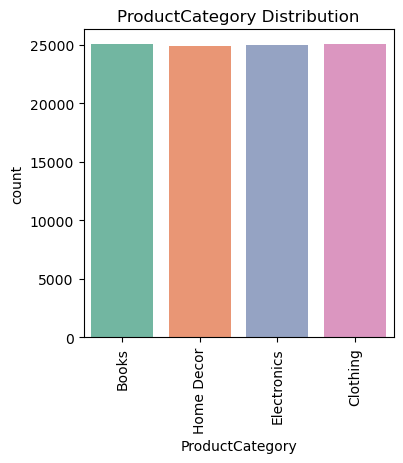

In [29]:
plt.figure(figsize=(4,4))
sns.countplot(x="ProductCategory",data=df,palette="Set2")
plt.title("ProductCategory Distribution")
plt.xticks(rotation=90)
plt.show();

C:\Users\A\AppData\Local\Temp\ipykernel_10168\1614639125.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PaymentMethod",data=df,palette="Set1")


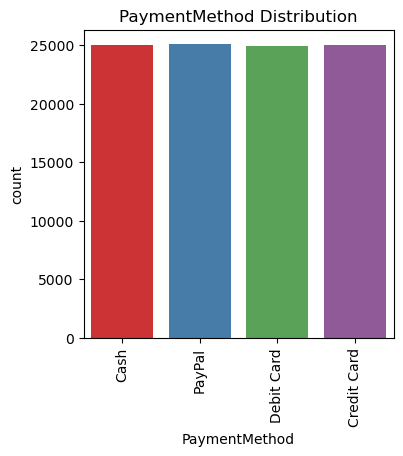

In [30]:
plt.figure(figsize=(4,4))
sns.countplot(x="PaymentMethod",data=df,palette="Set1")
plt.xticks(rotation=90)
plt.title("PaymentMethod Distribution")
plt.show();

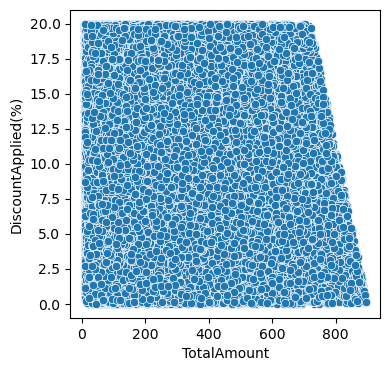

In [31]:
plt.figure(figsize=(4,4))
sns.scatterplot(x="TotalAmount",y="DiscountApplied(%)",data=df)
plt.show();

<Figure size 600x600 with 0 Axes>

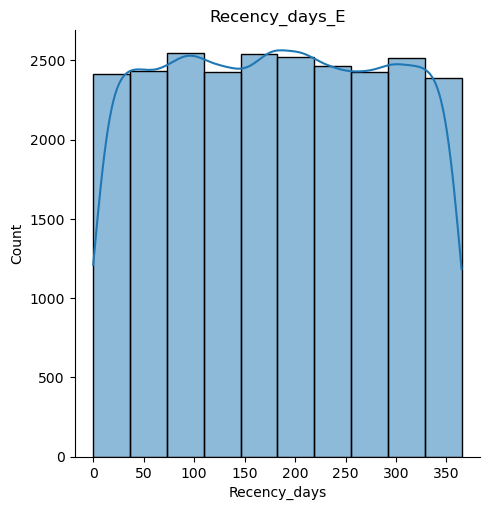

In [32]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="Recency_days",data=RM["RM_Electronics"],bins=10,kde=True)
plt.title("Recency_days_E")
plt.show();

<Figure size 600x600 with 0 Axes>

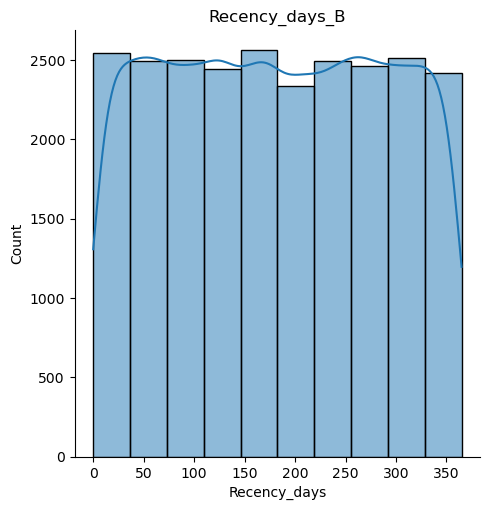

In [33]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="Recency_days",data=RM["RM_Books"],bins=10,kde=True)
plt.title("Recency_days_B")
plt.show();

<Figure size 600x600 with 0 Axes>

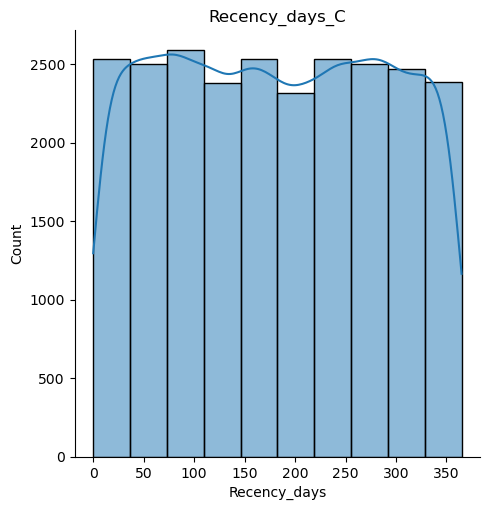

In [34]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="Recency_days",data=RM["RM_Clothing"],bins=10,kde=True)
plt.title("Recency_days_C")
plt.show();

<Figure size 600x600 with 0 Axes>

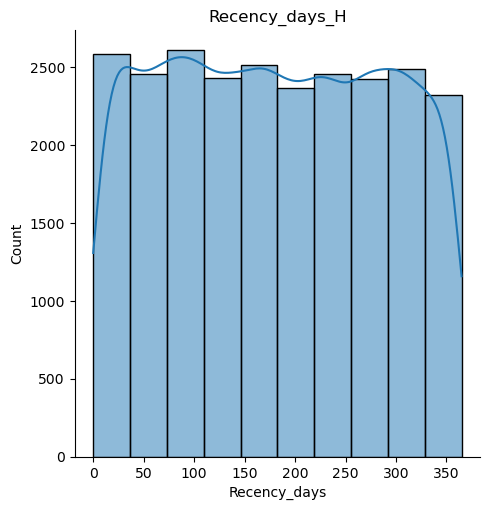

In [35]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="Recency_days",data=RM["RM_Home Decor"],bins=10,kde=True)
plt.title("Recency_days_H")
plt.show();

<Figure size 1200x600 with 0 Axes>

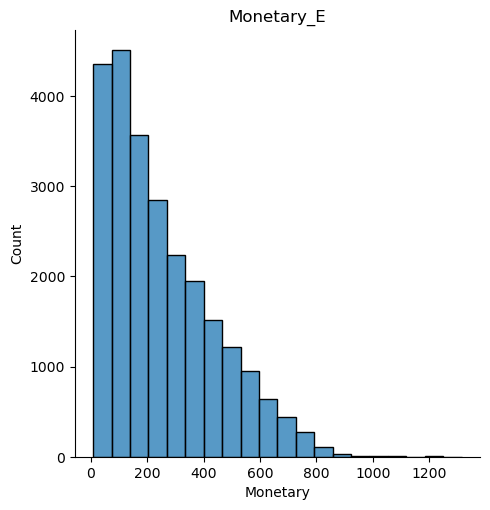

In [36]:
plt.figure(figsize=(8,4),dpi=150)
sns.displot(x="Monetary",data=RM["RM_Electronics"],bins=20)
plt.title("Monetary_E")
plt.show();

<Figure size 1200x600 with 0 Axes>

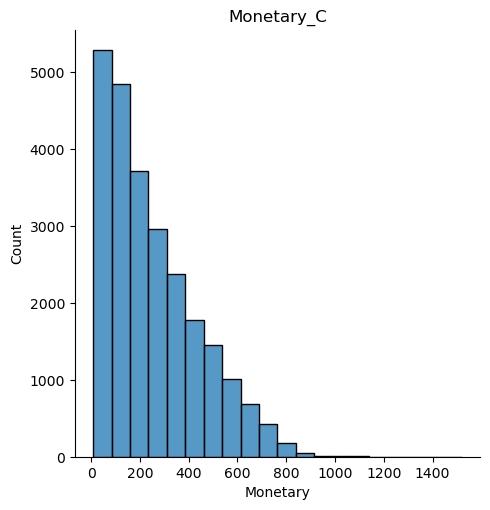

In [37]:
plt.figure(figsize=(8,4),dpi=150)
sns.displot(x="Monetary",data=RM["RM_Clothing"],bins=20)
plt.title("Monetary_C")
plt.show();

<Figure size 1200x600 with 0 Axes>

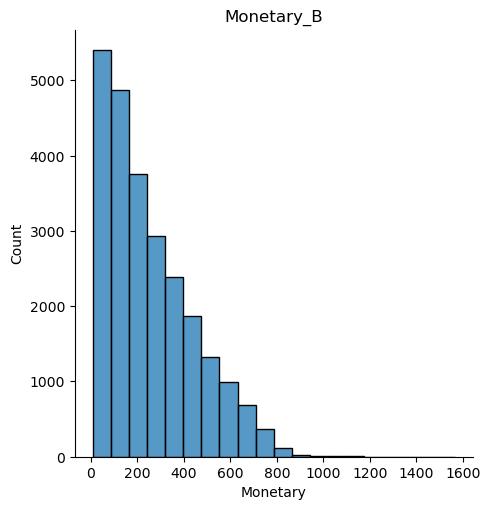

In [38]:
plt.figure(figsize=(8,4),dpi=150)
sns.displot(x="Monetary",data=RM["RM_Books"],bins=20)
plt.title("Monetary_B")
plt.show();

<Figure size 1200x600 with 0 Axes>

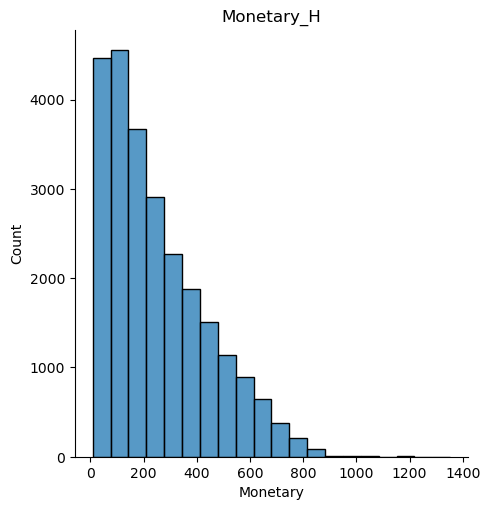

In [39]:
plt.figure(figsize=(8,4),dpi=150)
sns.displot(x="Monetary",data=RM["RM_Home Decor"],bins=20)
plt.title("Monetary_H")
plt.show();

Text(0.5, 1.0, 'AvgDiscount Hist_E')

<Figure size 600x600 with 0 Axes>

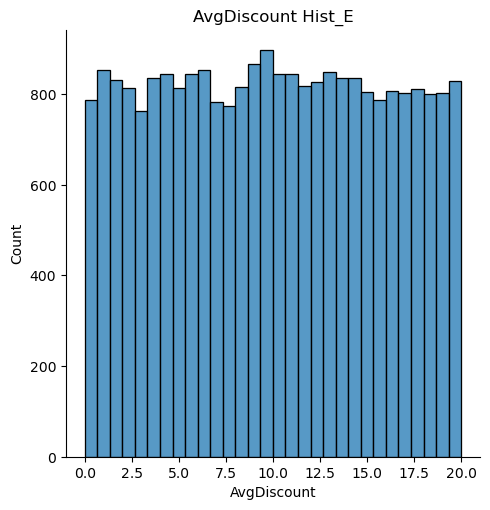

In [40]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="AvgDiscount",data=RM['RM_Electronics'])
plt.title("AvgDiscount Hist_E")

Text(0.5, 1.0, 'AvgDiscount Hist_C')

<Figure size 600x600 with 0 Axes>

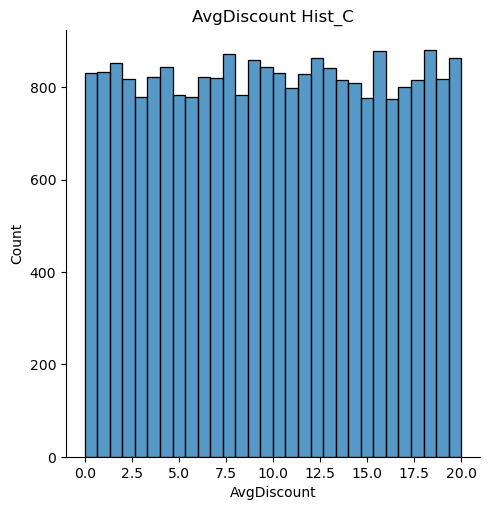

In [41]:
plt.figure(figsize=(4,4),dpi=150)
sns.displot(x="AvgDiscount",data=RM['RM_Clothing'])
plt.title("AvgDiscount Hist_C")

## Preprocessing & Modeling

To keep the pipeline simple and robust, I did **not** apply a log transform to Monetary.  
Instead, I used **RobustScaler** (median/IQR-based scaling) to reduce the impact of outliers while preserving interpretability.

**Workflow per `ProductCategory`:**
1. Build customer-level features (RM-style):  
   - `Monetary` = total spend per customer in the category  
   - `AvgDiscount` = average discount per customer in the category  
   - (`Recency_days` computed for profiling; excluded from training if it did not differentiate clusters)
2. Scale features using **RobustScaler**.
3. Train **KMeans** separately for each category.
4. Select `k` using **silhouette score + interpretability** (cluster size + median/IQR separation).
5. Convert numeric cluster IDs into **business-friendly segment names** (e.g., VIP / Promo-driven / Full-price).
6. Merge the segment labels back into the original transaction dataset using (`CustomerID`, `ProductCategory`).aries).

In [43]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
RM_scaled={}

for k,v in RM.items():
    RM_scaled[k+"_scaled"]=scaler.fit_transform(RM[k].drop(["Recency_days"],axis=1))

In [44]:
RM_scaled["RM_Electronics_scaled"][:,1]*=1.1

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [46]:
SSD=[]
SIL=[]

for n in range(2,10):
    model=KMeans(n_clusters=n)
    labels=model.fit_predict(RM_scaled["RM_Electronics_scaled"])
    SSD.append(model.inertia_)
    SIL.append(silhouette_score(RM_scaled["RM_Electronics_scaled"],labels))

[13430.953939757204,
 7760.39824944454,
 5868.833883842578,
 4883.400496648467,
 3888.2979040165865,
 3384.7930627501896,
 3043.9600559304254,
 2605.235060705749]

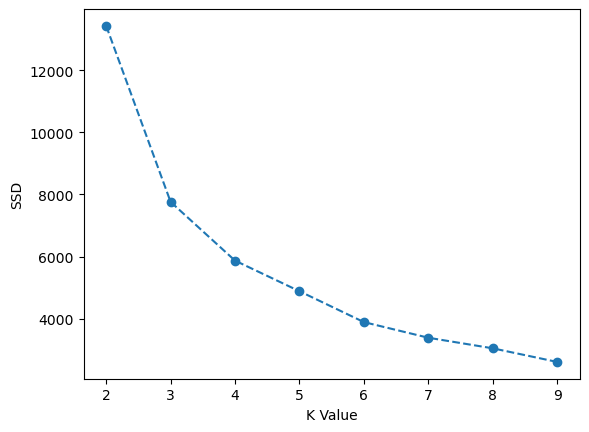

In [47]:
plt.plot(range(2,10),SSD,"o--")
plt.xlabel("K Value")
plt.ylabel("SSD")
SSD

Text(0, 0.5, 'SIL')

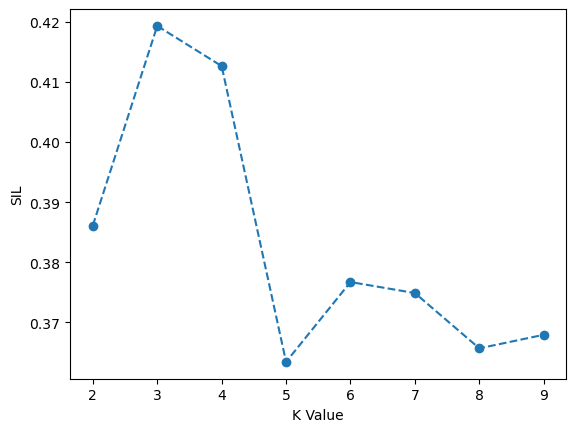

In [48]:
plt.plot(range(2,10),SIL,"o--")
plt.xlabel("K Value")
plt.ylabel("SIL")

In [49]:
model=KMeans(n_clusters=3,random_state=101,n_init=10)
labels=model.fit_predict(RM_scaled["RM_Electronics_scaled"])

In [50]:
model.cluster_centers_

array([[-0.15459194, -0.55466078],
       [-0.12605727,  0.59258285],
       [ 1.18501595, -0.12515788]])

In [51]:
model.inertia_

7760.08525935304

In [52]:
RM["RM_Electronics"]["Label"]=labels

In [53]:
RM["RM_Electronics"].groupby("Label").agg(
    n=("Label","size"),
    Monetary_median=("Monetary","median"),
    Monetary_p25=("Monetary", lambda x: x.quantile(.25)),
    Monetary_p75=("Monetary", lambda x: x.quantile(.75)),
    AvgDiscount_median=("AvgDiscount","median"),
    AvgDiscount_p25=("AvgDiscount", lambda x: x.quantile(.25)),
    AvgDiscount_p75=("AvgDiscount", lambda x: x.quantile(.75)),
).sort_values("Monetary_median", ascending=False)

,n,Monetary_median,Monetary_p25,Monetary_p75,AvgDiscount_median,AvgDiscount_p25,AvgDiscount_p75
Label,,,,,,,
2,5989,503.013190,426.375929,598.527881,8.745534,4.743138,12.597345
1,9721,150.069985,76.496589,243.800439,15.390066,12.858996,17.753654
0,8969,144.378033,78.555560,237.709372,4.916087,2.412902,7.514675


In [54]:
map_E={0:"Full-Price Regulars",1:"Promo Responders",2:"VIP Big Spenders"}
RM["RM_Electronics"]["Label"]=RM["RM_Electronics"]["Label"].map(map_E)

In [55]:
RM_scaled["RM_Books_scaled"][:,1]*=1.1
RM_scaled["RM_Books_scaled"]

array([[ 0.19271373,  0.60531057],
       [ 1.86633772, -0.81069178],
       [ 0.59372837, -0.32990162],
       ...,
       [-0.41911886, -0.58312947],
       [-0.58398311, -0.65763679],
       [-0.42890891,  1.08508404]])

In [56]:
SSD1=[]
SIL1=[]

for n in range(2,6):
    model1=KMeans(n_clusters=n)
    labels1=model1.fit_predict(RM_scaled["RM_Books_scaled"])
    SSD1.append(model1.inertia_)
    SIL1.append(silhouette_score(RM_scaled["RM_Books_scaled"],labels1))

Text(0, 0.5, 'SSD')

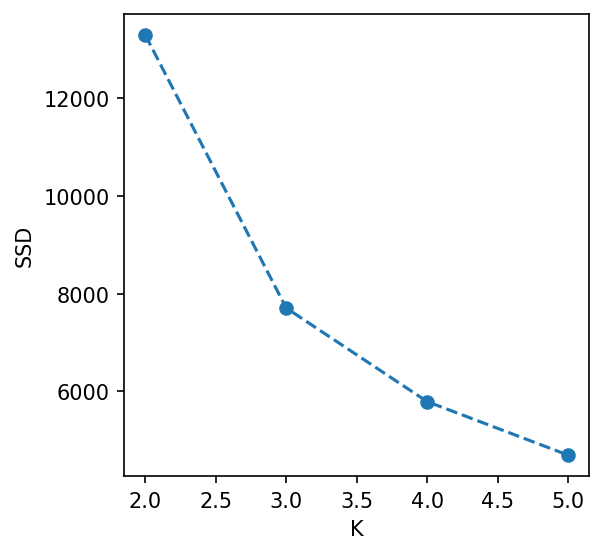

In [57]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SSD1,"o--")
plt.xlabel("K")
plt.ylabel("SSD")

Text(0, 0.5, 'SIL')

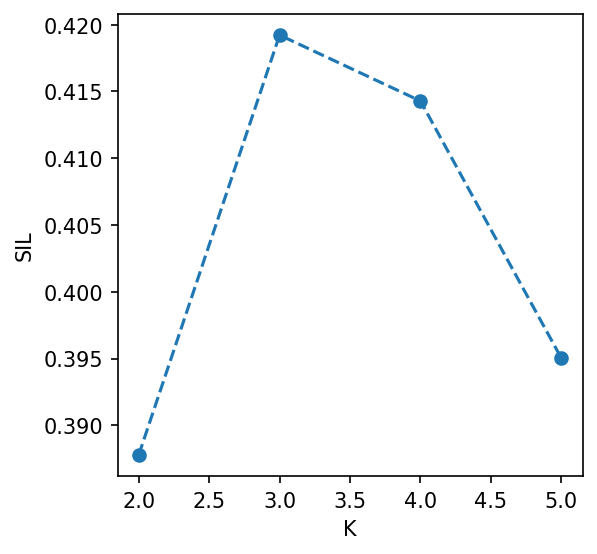

In [58]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SIL1,"o--")
plt.xlabel("K")
plt.ylabel("SIL")

In [59]:
model1=KMeans(n_clusters=3)
labels1=model1.fit_predict(RM_scaled["RM_Books_scaled"])

In [60]:
model.inertia_

7760.08525935304

In [61]:
model.cluster_centers_

array([[-0.15459194, -0.55466078],
       [-0.12605727,  0.59258285],
       [ 1.18501595, -0.12515788]])

In [62]:
RM["RM_Books"]["Label"]=labels1

In [63]:
RM["RM_Books"].groupby("Label").agg(
    n=("Label","size"),
    Monetary_median=("Monetary","median"),
    Monetary_p25=("Monetary",lambda x: x.quantile(.25)),
    Monetary_p75=("Monetary",lambda x: x.quantile(.75)),
    AvgDiscount=("AvgDiscount","median"),
    AvgDiscount_p25=("AvgDiscount",lambda x:x.quantile(.25)),
    AvgDiscount_p75=("AvgDiscount",lambda x:x.quantile(.75)),
).sort_values("Monetary_median",ascending=False)

,n,Monetary_median,Monetary_p25,Monetary_p75,AvgDiscount,AvgDiscount_p25,AvgDiscount_p75
Label,,,,,,,
1,6038,503.539625,427.586030,604.642970,8.946301,4.876772,13.070955
2,9005,150.669538,80.059543,240.200593,4.803258,2.396894,7.383647
0,9714,147.776261,76.014200,243.705923,15.422358,12.808316,17.792130


In [64]:
map_B={2:"Full-Price Regulars",0:"Promo Responders",1:"VIP Big Spenders"}
RM["RM_Books"]["Label"]=RM["RM_Books"]["Label"].map(map_B)

In [65]:
RM_scaled["RM_Clothing_scaled"][:,1]*=1.1
RM_scaled["RM_Clothing_scaled"]

array([[-0.23232462, -0.36121003],
       [ 1.28081047, -0.18719021],
       [-0.59577874, -0.36705306],
       ...,
       [-0.36041776,  0.00335632],
       [-0.02544306, -0.4067728 ],
       [-0.46944161,  0.76390925]])

In [66]:
SSD2=[]
SIL2=[]

for n in range(2,6):
    model2=KMeans(n_clusters=n,random_state=101,n_init=10)
    labels2=model2.fit_predict(RM_scaled["RM_Clothing_scaled"])
    SSD2.append(model2.inertia_)
    SIL2.append(silhouette_score(RM_scaled["RM_Clothing_scaled"],labels2))

Text(0, 0.5, 'SSD')

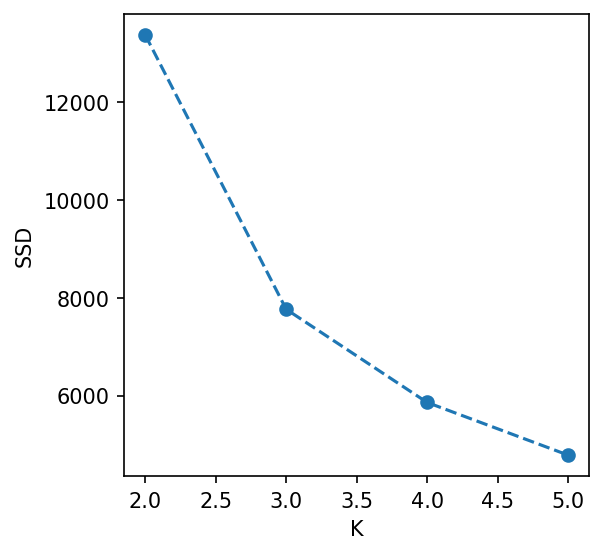

In [67]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SSD2,"o--")
plt.xlabel("K")
plt.ylabel("SSD")

Text(0, 0.5, 'SIL')

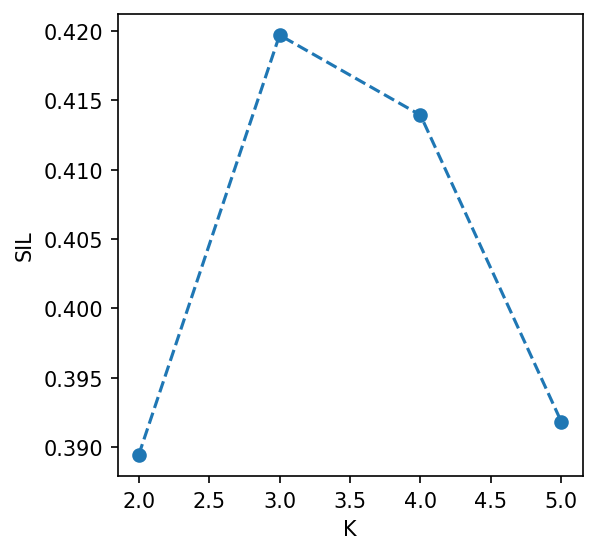

In [68]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SIL2,"o--")
plt.xlabel("K")
plt.ylabel("SIL")

In [69]:
model2=KMeans(n_clusters=3)
labels2=model2.fit_predict(RM_scaled["RM_Clothing_scaled"])

In [70]:
model2.inertia_

7764.729159985682

In [71]:
model2.cluster_centers_

array([[-0.14526339, -0.55342198],
       [-0.14076839,  0.58514258],
       [ 1.18936301, -0.10015298]])

In [72]:
RM["RM_Clothing"]["Label"]=labels2

In [73]:
RM["RM_Clothing"].groupby("Label").agg(
    n=("Label","size"),
    Monetary_median=("Monetary","median"),
    Monetary_p25=("Monetary",lambda x: x.quantile(.25)),
    Monetary_p75=("Monetary",lambda x: x.quantile(.75)),
    AvgDiscount=("AvgDiscount","median"),
    AvgDiscount_p25=("AvgDiscount",lambda x:x.quantile(.25)),
    AvgDiscount_p75=("AvgDiscount",lambda x:x.quantile(.75)),
).sort_values("Monetary_median",ascending=False)

,n,Monetary_median,Monetary_p25,Monetary_p75,AvgDiscount,AvgDiscount_p25,AvgDiscount_p75
Label,,,,,,,
2,5994,502.558484,429.617635,600.070754,9.076685,4.834915,13.039304
0,9097,148.596405,81.020792,239.301839,4.900114,2.397321,7.507298
1,9645,144.162388,74.147438,241.380745,15.503345,12.869305,17.831168


In [74]:
map_C={0:"Full-Price Regulars",1:"Promo Responders",2:"VIP Big Spenders"}
RM["RM_Clothing"]["Label"]=RM["RM_Clothing"]["Label"].map(map_C)

In [75]:
RM_scaled["RM_Home Decor_scaled"][:,1]*=1.1
RM_scaled["RM_Home Decor_scaled"]

array([[ 1.12660105,  1.00382939],
       [-0.34478517, -0.27980331],
       [-0.30784545,  0.01686608],
       ...,
       [ 0.98763344,  0.28251707],
       [-0.06026631,  1.00007181],
       [-0.30515155,  0.89989503]])

In [76]:
SSD3=[]
SIL3=[]

for n in range(2,6):
    model3=KMeans(n_clusters=n,random_state=101,n_init=10)
    labels3=model3.fit_predict(RM_scaled["RM_Home Decor_scaled"])
    SSD3.append(model3.inertia_)
    SIL3.append(silhouette_score(RM_scaled["RM_Home Decor_scaled"],labels3))

Text(0, 0.5, 'SSD')

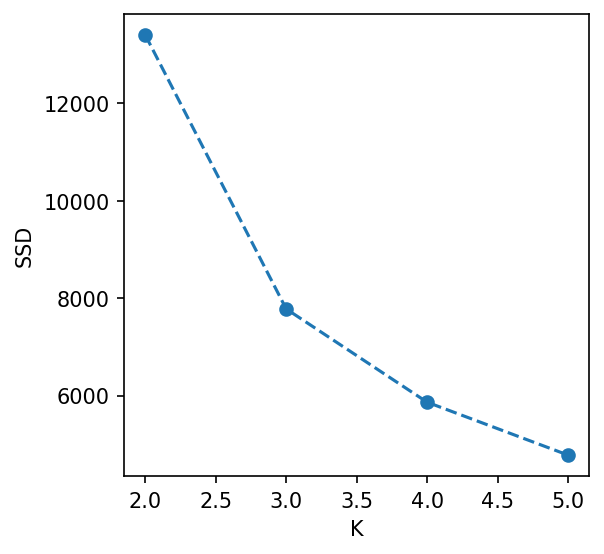

In [77]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SSD3,"o--")
plt.xlabel("K")
plt.ylabel("SSD")

Text(0, 0.5, 'SIL')

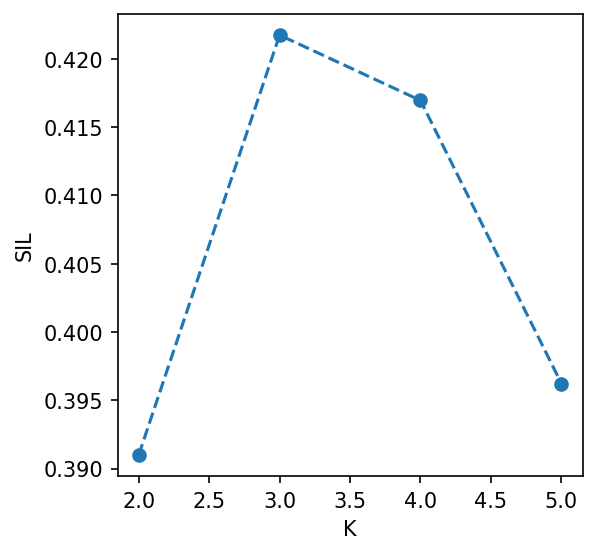

In [78]:
plt.figure(figsize=(4,4),dpi=150)
plt.plot(range(2,6),SIL3,"o--")
plt.xlabel("K")
plt.ylabel("SIL")

In [79]:
model3=KMeans(n_clusters=3)
labels3=model3.fit_predict(RM_scaled["RM_Home Decor_scaled"])

In [80]:
model3.inertia_

7776.512563250136

In [81]:
model3.cluster_centers_

array([[-0.14710631,  0.56970012],
       [-0.14755016, -0.5721115 ],
       [ 1.19563935, -0.11249764]])

In [82]:
RM["RM_Home Decor"]["Label"]=labels3

In [83]:
RM["RM_Home Decor"].groupby("Label").agg(
    n=("Label","size"),
    Monetary_median=("Monetary","median"),
    Monetary_p25=("Monetary",lambda x: x.quantile(.25)),
    Monetary_p75=("Monetary",lambda x: x.quantile(.75)),
    AvgDiscount=("AvgDiscount","median"),
    AvgDiscount_p25=("AvgDiscount",lambda x:x.quantile(.25)),
    AvgDiscount_p75=("AvgDiscount",lambda x:x.quantile(.75)),
).sort_values("Monetary_median",ascending=False)

,n,Monetary_median,Monetary_p25,Monetary_p75,AvgDiscount,AvgDiscount_p25,AvgDiscount_p75
Label,,,,,,,
2,6063,498.834533,425.709588,599.063633,8.952919,4.898613,13.019474
1,8812,147.919287,80.630099,237.765313,4.960153,2.445445,7.516360
0,9763,145.349244,75.189892,237.877914,15.376389,12.905833,17.705646


In [84]:
map_H={0:"Full-Price Regulars",2:"Promo Responders",1:"VIP Big Spenders"}
RM["RM_Home Decor"]["Label"]=RM["RM_Home Decor"]["Label"].map(map_H)

In [85]:
parts = []
for key, rm_cat in RM.items():
    cat = key.replace("RM_", "")
    tmp = rm_cat.copy()
    tmp["ProductCategory"] = cat
    keep_cols = ["ProductCategory"]
    if "Label" in tmp.columns: keep_cols.append("Label")
    if "SegmentName" in tmp.columns: keep_cols.append("SegmentName")
    tmp = tmp[keep_cols].reset_index().rename(columns={"index": "CustomerID"})
    parts.append(tmp)

seg_map = pd.concat(parts, ignore_index=True)

In [86]:
seg_map.duplicated(["CustomerID","ProductCategory"]).sum()

0

In [87]:
df["ProductCategory"] = df["ProductCategory"].astype(str).str.strip()
seg_map["ProductCategory"] = seg_map["ProductCategory"].astype(str).str.strip()
df["CustomerID"] = df["CustomerID"].astype(int)
seg_map["CustomerID"] = seg_map["CustomerID"].astype(int)

In [88]:
df["_row"] = np.arange(len(df))
df_out = df.merge(
    seg_map,
    on=["CustomerID","ProductCategory"],
    how="left",
    validate="m:1"
).sort_values("_row").drop(columns=["_row"])

In [89]:
len(df),len(df_out)

(100000, 100000)

In [90]:
df_out

,CustomerID,ProductID,Quantity,Price,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,DATE,Label
0,109318,C,7,80.079844,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2023-12-26 12:32:00,VIP Big Spenders
1,993229,C,4,75.195229,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2023-08-05 00:00:00,Full-Price Regulars
2,579675,A,8,31.528816,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2024-03-11 18:51:00,Promo Responders
3,799826,D,5,98.880218,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2023-10-27 22:00:00,VIP Big Spenders
4,121413,A,7,93.188512,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2023-12-22 11:38:00,VIP Big Spenders
...,...,...,...,...,...,...,...,...,...,...,...
99995,726461,A,2,56.078258,Credit Card,"3632 Darren Station Apt. 553\nEricaborough, RI...",Clothing,18.345145,91.581240,2023-07-17 16:59:00,Promo Responders
99996,328056,A,6,88.516406,Credit Card,"821 Taylor Shoals\nEvansville, IL 70845",Electronics,3.995541,509.878179,2023-05-30 09:04:00,VIP Big Spenders
99997,887304,B,4,72.385564,Credit Card,"50653 Kara Lakes\nStephanieborough, RI 94492",Clothing,17.423979,239.092472,2023-08-25 07:59:00,Promo Responders
99998,326401,C,5,66.542239,PayPal,"18756 Mcfarland Way Suite 866\nBarnettside, PR...",Electronics,14.345018,284.983717,2024-02-05 19:45:00,Promo Responders
